In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

from utils.mapping import SERIES_NAME_MAPPING, SERIES_NAME_MAPPING_2
from utils.plotTools import saving_manager, darken_color, format_time

In [95]:
results_dir = r'..\results'
plot_dir = fr'..\plots\General'

should_save = False
make_it_fancy = True

In [96]:
all_data_temporal = []
all_data_simulation = []
all_data_volcanic = []

for experiment_name in os.listdir(results_dir):
    experiment_path = os.path.join(results_dir, experiment_name)
    if os.path.isdir(experiment_path):
        experiment_id = experiment_name
        for run_name in os.listdir(experiment_path):
            run_path = os.path.join(experiment_path, run_name)
            if os.path.isdir(run_path):
                run_id = run_name
                file_temporal = os.path.join(run_path, 'temporal_series_recorder.csv')
                file_simulation = os.path.join(run_path, 'simulation_recorder.csv')
                file_volcanic = os.path.join(run_path, 'volcanic_recorder.csv')
                if os.path.exists(file_temporal):
                    df_temporal = pd.read_csv(file_temporal)
                    df_temporal['run_id'] = run_id
                    df_temporal['experiment_id'] = experiment_id
                    all_data_temporal.append(df_temporal)

                    df_simulation = pd.read_csv(file_simulation)
                    df_simulation['run_id'] = run_id
                    df_simulation['experiment_id'] = experiment_id
                    all_data_simulation.append(df_simulation)

                    df_volcanic = pd.read_csv(file_volcanic)
                    df_volcanic['run_id'] = run_id
                    df_volcanic['experiment_id'] = experiment_id
                    all_data_volcanic.append(df_volcanic)

temporal_df = pd.concat(all_data_temporal, ignore_index=True)
simulation_df = pd.concat(all_data_simulation, ignore_index=True)
volcanic_df = pd.concat(all_data_volcanic, ignore_index=True)

with pd.option_context('display.width', 1000, 'display.max_columns', None):
    print(simulation_df.head(100))

print(temporal_df['experiment_id'].unique())

    event_time                                     event_name                                              notes               run_id experiment_id
0            0                       Volcanic Activity Update     Volcano LaFossawent from activity level 1 to 2  0.08837391973276298       prova 3
1         1798  Population Evacuation Order - IT Alert issued  Civil defense ordered evacuation of civil popu...  0.08837391973276298       prova 3
2         1799                        Backups Reached Vulcano  20 backup LEAs arrived on the Island. Ordered ...  0.08837391973276298       prova 3
3        14794                          LEAs Evacuation Order  Civil defense ordered evacuation of Law Enforc...  0.08837391973276298       prova 3
4        18566                     Civil Evacuation Completed  The evacuation of civil population was completed.  0.08837391973276298       prova 3
..         ...                                            ...                                                ...

In [97]:
simulation_df['event_time'] = pd.to_numeric(simulation_df['event_time'])
grouped = simulation_df.groupby(['experiment_id', 'run_id'])

time_data = []

for (experiment_id, run_id), group_df in grouped:
    pop_evac_time_series = group_df[group_df['event_name'].str.contains('Population Evacuation Order', na=False, regex=False)]['event_time']
    civil_evac_completed_time_series = group_df[group_df['event_name'] == 'Civil Evacuation Completed']['event_time']
    evac_completed_time_series = group_df[group_df['event_name'] == 'Evacuation Completed']['event_time']

    pop_evac_time = pop_evac_time_series.iloc[0] if not pop_evac_time_series.empty else None
    civil_evac_completed_time = civil_evac_completed_time_series.iloc[0] if not civil_evac_completed_time_series.empty else None
    evac_completed_time = evac_completed_time_series.iloc[0] if not evac_completed_time_series.empty else None

    civil_evac_duration = (civil_evac_completed_time - pop_evac_time) if pop_evac_time is not None and civil_evac_completed_time is not None else None
    evac_duration = (evac_completed_time - pop_evac_time) if pop_evac_time is not None and evac_completed_time is not None else None

    time_data.append({
        'experiment_id': experiment_id,
        'run_id': run_id,
        'Civil Evacuation Duration': civil_evac_duration,
        'Full Evacuation Duration': evac_duration,
    })

time_df = pd.DataFrame(time_data)

In [98]:
with pd.option_context('display.width', 1000, 'display.max_columns', None):
    print(time_df.head(10))

  experiment_id               run_id  Civil Evacuation Duration  Full Evacuation Duration
0       prova 3  0.08837391973276298                      16768                     17737
1       prova 3                  0.2                      29962                     30997
2       prova 3                  0.4                      22013                     23054
3       prova 3   0.6000000000000001                      25592                     26632
4       prova 3                  0.8                      12514                     15288
5       prova 3                  1.0                      20051                     21043
6       prova 3                  1.2                      19748                     20855
7       prova 4                  0.2                      34593                     35665
8       prova 4                  0.4                      25596                     26567
9       prova 4   0.6000000000000001                      37257                     38304


In [99]:
summary_df = time_df.groupby('experiment_id').agg(
    Mean_Civil_Evacuation_Time=('Civil Evacuation Duration', 'mean'),
    Std_Civil_Evacuation_Time=('Civil Evacuation Duration', 'std'),
    Mean_Full_Evacuation_Time=('Full Evacuation Duration', 'mean'),
    Std_Full_Evacuation_Time=('Full Evacuation Duration', 'std')
).reset_index()

# Merge the summary DataFrame back into the original new_df DataFrame on 'experiment_id'
time_df = pd.merge(time_df, summary_df, on='experiment_id', how='left')

if should_save:
    time_df.to_csv(os.path.join(plot_dir,'time.csv')) 

In [100]:
with pd.option_context('display.width', 1000, 'display.max_columns', None):
    print(time_df.head(10))

  experiment_id               run_id  Civil Evacuation Duration  Full Evacuation Duration  Mean_Civil_Evacuation_Time  Std_Civil_Evacuation_Time  Mean_Full_Evacuation_Time  Std_Full_Evacuation_Time
0       prova 3  0.08837391973276298                      16768                     17737                20949.714286                5697.989432               22229.428571               5300.862724
1       prova 3                  0.2                      29962                     30997                20949.714286                5697.989432               22229.428571               5300.862724
2       prova 3                  0.4                      22013                     23054                20949.714286                5697.989432               22229.428571               5300.862724
3       prova 3   0.6000000000000001                      25592                     26632                20949.714286                5697.989432               22229.428571               5300.862724
4       pr

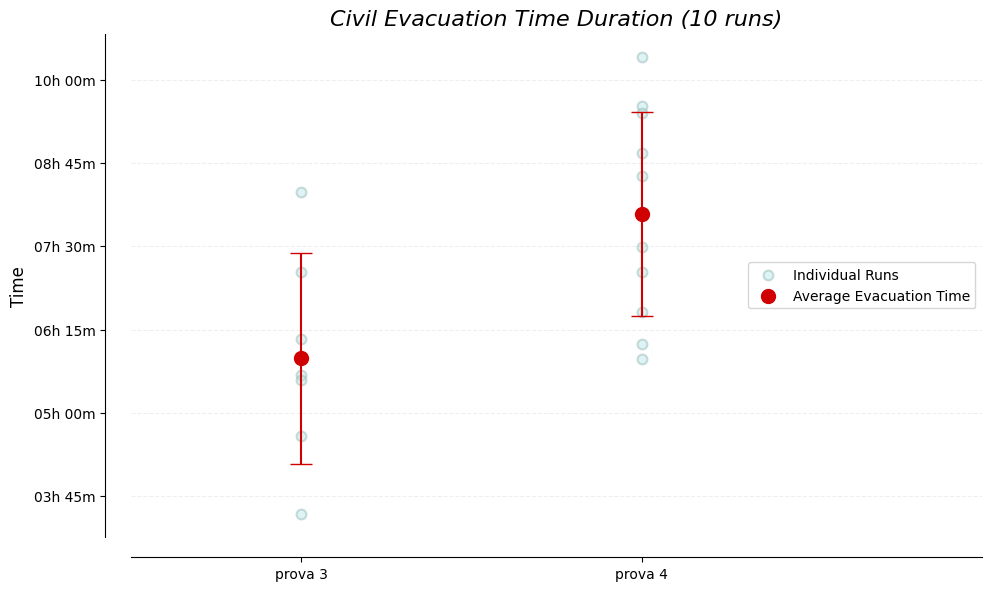

Plot not saved. Remember to set should_save to True if you want to save it.


In [110]:
plot_filename = 'civil_evacuation_duration.png'

single_run_color = "#bee9e8"
avg_color = '#d00000'

fig, ax = plt.subplots(figsize=(10, 6))

x_positions = {}
for i, experiment_name in enumerate(time_df['experiment_id'].unique()):
    x_positions[experiment_name] = i + 1

time_df['x_pos'] = time_df['experiment_id'].map(x_positions)

scatter_handle = ax.scatter(
    x=time_df['x_pos'],
    y=time_df['Civil Evacuation Duration'],
    marker = 'o',
    s=50,
    edgecolor=darken_color(single_run_color),
    linewidth=1.5,
    alpha=0.5,
    color=single_run_color,
    label='Individual Runs'
)

avg_points_handle = ax.scatter(
    x=time_df.groupby('experiment_id')['x_pos'].first(),
    y=time_df.groupby('experiment_id')['Mean_Civil_Evacuation_Time'].first(),
    marker='o',
    s=100,
    color=avg_color,
    label='' 
)

error_bars_handle = ax.errorbar(
    x=time_df.groupby('experiment_id')['x_pos'].first(),
    y=time_df.groupby('experiment_id')['Mean_Civil_Evacuation_Time'].first(),
    yerr=time_df.groupby('experiment_id')['Std_Civil_Evacuation_Time'].first(),
    fmt='none',  
    capsize=8,
    color=avg_color,
    label=''
)


ax.set_title('Civil Evacuation Time Duration (10 runs)', fontsize=16, fontstyle='italic')

x_tick_labels = time_df['experiment_id'].unique()
x_tick_positions = [x_positions[label] for label in x_tick_labels]
ax.set_xticks(x_tick_positions)
ax.set_xticklabels(x_tick_labels)
time_format = "hh mm"
time_formatter = lambda t, pos: format_time(t, format=time_format)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(time_formatter))
tick_interval = 4500
ax.yaxis.set_major_locator(mticker.MultipleLocator(tick_interval))

handles = [scatter_handle, avg_points_handle]
labels = ['Individual Runs', 'Average Evacuation Time']
ax.legend(handles, labels, loc='center right')
# ax.set_xlabel('Experiment ID', fontsize=12)
ax.set_ylabel('Time', fontsize=12)
ax.set_xlim(0.5, time_df['x_pos'].max()+1)
if make_it_fancy:
    ax = plt.gca()
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.spines['bottom'].set_position(('axes', -0.04))
    ax.spines['left'].set_position(('axes', -0.03))

ax.grid(True, axis='y', linestyle='--', alpha=0.2)
plt.tight_layout()
plot_filepath=os.path.join(plot_dir, plot_filename)
saving_manager(should_save=should_save, save_path=plot_filepath, should_show=True)

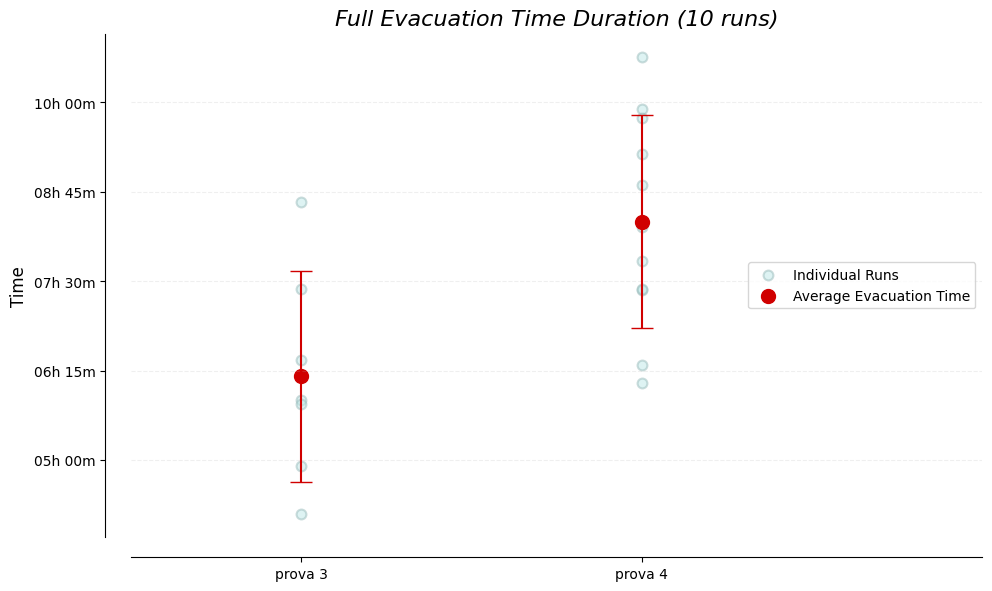

Plot not saved. Remember to set should_save to True if you want to save it.


In [111]:
plot_filename = 'full_evacuation_duration.png'

single_run_color = "#bee9e8"
avg_color = '#d00000'

fig, ax = plt.subplots(figsize=(10, 6))

x_positions = {}
for i, experiment_name in enumerate(time_df['experiment_id'].unique()):
    x_positions[experiment_name] = i + 1

time_df['x_pos'] = time_df['experiment_id'].map(x_positions)

scatter_handle = ax.scatter(
    x=time_df['x_pos'],
    y=time_df['Full Evacuation Duration'],
    marker = 'o',
    s=50,
    edgecolor=darken_color(single_run_color),
    linewidth=1.5,
    alpha=0.5,
    color=single_run_color,
    label='Individual Runs'
)

avg_points_handle = ax.scatter(
    x=time_df.groupby('experiment_id')['x_pos'].first(),
    y=time_df.groupby('experiment_id')['Mean_Full_Evacuation_Time'].first(),
    marker='o',
    s=100,
    color=avg_color,
    label='' 
)

error_bars_handle = ax.errorbar(
    x=time_df.groupby('experiment_id')['x_pos'].first(),
    y=time_df.groupby('experiment_id')['Mean_Full_Evacuation_Time'].first(),
    yerr=time_df.groupby('experiment_id')['Std_Full_Evacuation_Time'].first(),
    fmt='none',  
    capsize=8,
    color=avg_color,
    label=''
)


ax.set_title('Full Evacuation Time Duration (10 runs)', fontsize=16, fontstyle='italic')

x_tick_labels = time_df['experiment_id'].unique()
x_tick_positions = [x_positions[label] for label in x_tick_labels]
ax.set_xticks(x_tick_positions)
ax.set_xticklabels(x_tick_labels)
time_formatter = lambda t, pos: format_time(t, format=time_format)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(time_formatter))
tick_interval = 4500
ax.yaxis.set_major_locator(mticker.MultipleLocator(tick_interval))

handles = [scatter_handle, avg_points_handle]
labels = ['Individual Runs', 'Average Evacuation Time']
ax.legend(handles, labels, loc='center right')
# ax.set_xlabel('Experiment ID', fontsize=12)
ax.set_ylabel('Time', fontsize=12)
ax.set_xlim(0.5, time_df['x_pos'].max()+1)
if make_it_fancy:
    ax = plt.gca()
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.spines['bottom'].set_position(('axes', -0.04))
    ax.spines['left'].set_position(('axes', -0.03))

ax.grid(True, axis='y', linestyle='--', alpha=0.2)
plt.tight_layout()
plot_filepath=os.path.join(plot_dir, plot_filename)
saving_manager(should_save=should_save, save_path=plot_filepath, should_show=True)